In [23]:
import os
import re
import sys
import time
import getopt
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from pathlib import Path
sys.path.append("/home/users/mnergiz/softwares/licsar_extra/python")  # adjust as needed
import datetime as dt
from lics_tstools import load_licsbas_cumh5_as_xrda
from lics_tstools import generate_pmm_velocity
from lics_tstools import load_tif2xr
import pandas as pd

In [24]:
def da_to_xyz(da, out_path, varname=None):
    # Standardize coord names
    if "x" in da.dims: da = da.rename({"x": "lon"})
    if "y" in da.dims: da = da.rename({"y": "lat"})
    if "longitude" in da.dims: da = da.rename({"longitude": "lon"})
    if "latitude" in da.dims:  da = da.rename({"latitude":  "lat"})

    name = varname or (da.name if da.name else "z")
    da = da.rename(name)

    # Flatten -> DataFrame (lon, lat, value)
    df = (
        da.stack(pt=("lat", "lon"))
          .to_series()
          .dropna()
          .reset_index()
          .rename(columns={name: "value"})
          [ ["lon", "lat", "value"] ]
    )

    # Create parent dir only if one was provided
    parent = os.path.dirname(out_path)
    if parent:
        os.makedirs(parent, exist_ok=True)

    # Write XYZ (space-separated, no header)
    df.to_csv(out_path, sep=" ", header=False, index=False)


In [25]:
def _get_pixel_window(da, reference, halfwin=4):
    """
    Return a subset window around the nearest pixel to (lon, lat).

    halfwin=4 means:
      x: ix-4 ... ix+4
      y: iy-4 ... iy+4
    i.e. a 9x9 window.
    """
    lon0, lat0 = reference

    # nearest pixel index
    ix = int(np.abs(da.lon.values - lon0).argmin())
    iy = int(np.abs(da.lat.values - lat0).argmin())

    # clip to image boundaries
    x1 = max(0, ix - halfwin)
    x2 = min(da.sizes["lon"], ix + halfwin + 1)
    y1 = max(0, iy - halfwin)
    y2 = min(da.sizes["lat"], iy + halfwin + 1)

    return da.isel(lon=slice(x1, x2), lat=slice(y1, y2))


def spatial_reference_2d(da, reference, use_nearest=False, halfwin=4):
    """
    Spatially reference a 2D DataArray (lat, lon) to a point
    or to the mean of a pixel window around that point.

    Parameters
    ----------
    da : xarray.DataArray
        2D array with dims (lat, lon)
    reference : tuple
        (lon, lat)
    use_nearest : bool
        If True, use nearest single pixel.
        If False, use mean over window defined by halfwin.
    halfwin : int
        Half window size in pixels. halfwin=4 => 9x9 window.
    """
    da = da.where(da != 0)

    if use_nearest:
        ref_val = da.sel(lon=reference[0], lat=reference[1], method="nearest")
    else:
        ref_win = _get_pixel_window(da, reference, halfwin=halfwin)
        ref_val = ref_win.mean(dim=("lat", "lon"), skipna=True)

    if np.isnan(ref_val.values):
        ref_val = da.sel(lon=reference[0], lat=reference[1], method="nearest")

    return da - ref_val


def reference_ts_dataset(ds, reference, vars_to_ref=None, use_nearest=False, halfwin=4, verbose=True):

    if vars_to_ref is None:
        vars_to_ref = ["cum", "iono", "tide", "sltd"]

    ds_ref = ds.copy()

    for v in vars_to_ref:
        if v not in ds.data_vars:
            if verbose:
                print(f"Skipping '{v}': not found in dataset")
            continue

        da = ds[v]

        # ensure required dims exist
        if not {"time","lat","lon"}.issubset(da.dims):
            if verbose:
                print(f"Skipping '{v}': dims are {da.dims}")
            continue

        # 1) temporal reference
        da_tref = da - da.isel(time=0)

        if use_nearest:

            ref_ts = da_tref.sel(
                lon=reference[0],
                lat=reference[1],
                method="nearest"
            )

        else:
            # find nearest pixel index
            ix = int(np.abs(da.lon.values - reference[0]).argmin())
            iy = int(np.abs(da.lat.values - reference[1]).argmin())

            x1 = max(0, ix-halfwin)
            x2 = min(da.sizes["lon"], ix+halfwin+1)
            y1 = max(0, iy-halfwin)
            y2 = min(da.sizes["lat"], iy+halfwin+1)

            # extract window for all times
            ref_win = da_tref.isel(lon=slice(x1,x2), lat=slice(y1,y2))

            # average window → reference time series
            ref_ts = ref_win.mean(dim=("lat","lon"), skipna=True)

        ds_ref[v] = da_tref - ref_ts

        if verbose:
            if use_nearest:
                print(f"Referenced '{v}' using nearest pixel")
            else:
                print(f"Referenced '{v}' using ±{halfwin} pixel window")

    return ds_ref

def extract_ts_window_mean(da, point, halfwin=4):
    """
    Extract a time series from a (time, lat, lon) DataArray
    using the mean of a window around the nearest pixel to point.

    Parameters
    ----------
    da : xarray.DataArray
        Must have dims including (time, lat, lon)
    point : tuple
        (lon, lat)
    halfwin : int
        Half window size in pixels. halfwin=4 => 9x9 window

    Returns
    -------
    ts : xarray.DataArray
        1D time series
    """
    ix = int(np.abs(da.lon.values - point[0]).argmin())
    iy = int(np.abs(da.lat.values - point[1]).argmin())

    x1 = max(0, ix - halfwin)
    x2 = min(da.sizes["lon"], ix + halfwin + 1)
    y1 = max(0, iy - halfwin)
    y2 = min(da.sizes["lat"], iy + halfwin + 1)

    win = da.isel(lon=slice(x1, x2), lat=slice(y1, y2))
    ts = win.mean(dim=("lat", "lon"), skipna=True)

    return ts

In [26]:
os.environ["LiCSAR_public"] = "/gws/ssde/j25a/nceo_geohazards/vol1/public/LiCSAR_products.public/"
frame="021D_05266_252525"
sbovl=True
path="/work/scratch-pw4/licsar/mnergiz/TR_postseismic_13032026/sboi/021D_05266_252525"
TS_folder_uncor = "/work/scratch-pw4/licsar/mnergiz/TR_postseismic_13032026/sboi/021D_05266_252525/TS_GEOCml10mask"
GEOC_folder_uncor = os.path.join(os.path.dirname(os.path.normpath(TS_folder_uncor)), "GEOCml10mask")
cumfile_uncor=f"{TS_folder_uncor}/cum.h5"
cum_uncor = load_licsbas_cumh5_as_xrda(cumfile_uncor)

# TS_folder_cor = "/work/scratch-pw4/licsar/mnergiz/TR_postseismic_13032026/reunw/021D_05266_252525/TS_GEOCml10GACOS"
# GEOC_folder_cor = os.path.join(os.path.dirname(os.path.normpath(TS_folder_cor)), "GEOCml10GACOS")
# cumfile_cor=f"{TS_folder_cor}/cum.h5"
# cum_cor = load_licsbas_cumh5_as_xrda(cumfile_cor)

#plotting and reference points
if sbovl:
    reference=(37.68, 36.37) #lon lat
    point1=(38.25, 38.347) #lon lat
else:
    reference=(37.68, 36.37) #lon lat
    point1=(36.7, 38.2) #lon lat

#years calculation
years = (cum_uncor.time[-1] - cum_uncor.time[0]) / np.timedelta64(1, 'D') / 365.25
print(float(years))

getfattr: Removing leading '/' from absolute path names


1.8726899383983573


In [27]:
if sbovl:
    vars_to_ref = ["cum", "iono", "tide"]
else:
    vars_to_ref = ["cum", "iono", "tide", "sltd"]

# cum_cor_ref = reference_ts_dataset(
#     cum_cor,
#     reference=reference,
#     vars_to_ref=vars_to_ref,
#     use_nearest=False,
#     halfwin=4,
#     verbose=True
# )

cum_uncor_ref = reference_ts_dataset(
    cum_uncor,
    reference=reference,
    vars_to_ref=vars_to_ref,
    use_nearest=False,
    halfwin=4,
    verbose=True
)

Referenced 'cum' using ±4 pixel window
Referenced 'iono' using ±4 pixel window
Referenced 'tide' using ±4 pixel window


In [28]:
time_years = xr.DataArray(
    (cum_uncor.time.values - cum_uncor.time.values[0]) / np.timedelta64(1, 'D') / 365.25,
    coords={"time": cum_uncor.time.values},
    dims=["time"]
)

# -------------------------
# Plate motion correction
# -------------------------
vlos_eurasia = generate_pmm_velocity(frame, 'Eurasia', 'GEOC', azi=sbovl)
vlos_eurasia_reshaped = vlos_eurasia.interp_like(cum_uncor.vel)

plate_motion_cumulative = vlos_eurasia_reshaped * time_years

# -------------------------
# Interseismic correction
# -------------------------
#interseismic model
ve_gnss_nc='/gws/ssde/j25a/nceo_geohazards/vol1/projects/COMET/mnergizci/1.second_paper/interseismic/decomp3d.nc'
vn_gnss_nc='/gws/ssde/j25a/nceo_geohazards/vol1/projects/COMET/mnergizci/1.second_paper/interseismic/velmap_insars29_sbois0_scalar.nc'
#ENU unit vectors
if sbovl:
    E_unit=load_tif2xr(f'{path}/{frame}.E.azi.geo.tif')
    N_unit=load_tif2xr(f'{path}/{frame}.N.azi.geo.tif')
    # azimuth has no vertical sensitivity
    U_unit = xr.zeros_like(E_unit)
else:
    E_unit=load_tif2xr(f'{path}/{frame}.E.geo.tif')
    N_unit=load_tif2xr(f'{path}/{frame}.N.geo.tif')
    U_unit=load_tif2xr(f'{path}/{frame}.U.geo.tif')


ve_gnss = xr.load_dataset(ve_gnss_nc).Ve
vn_gnss = xr.load_dataset(vn_gnss_nc).Vn

ve_gnss_reshaped = ve_gnss.interp_like(E_unit)
vn_gnss_reshaped = vn_gnss.interp_like(E_unit)

interseismic_velo = ve_gnss_reshaped * E_unit + vn_gnss_reshaped * N_unit
interseismic_velo_reshaped = interseismic_velo.interp_like(cum_uncor.vel)
interseismic_velo_cumulative = interseismic_velo_reshaped * time_years

assume a spheroidal Earth as defined in WGS84
Interpolating the plate velocity ENU vectors to the original frame resolution
Calculating the plate motion velocity in LOS (please check the sign here)


In [29]:
ds_plate = xr.Dataset({"plate": plate_motion_cumulative})
ds_plate_ref = reference_ts_dataset(
    ds_plate,
    reference=reference,
    vars_to_ref=["plate"],
    use_nearest=False,
    halfwin=4,
    verbose=True
)

ds_inter = xr.Dataset({"interseismic": interseismic_velo_cumulative})
ds_inter_ref = reference_ts_dataset(
    ds_inter,
    reference=reference,
    vars_to_ref=["interseismic"],
    use_nearest=False,
    halfwin=4,
    verbose=True
)

plate_motion_cumulative_ref = ds_plate_ref["plate"]
interseismic_velo_cumulative_ref = ds_inter_ref["interseismic"]

Referenced 'plate' using ±4 pixel window
Referenced 'interseismic' using ±4 pixel window


In [30]:
tide_ts = extract_ts_window_mean(cum_uncor_ref["tide"], point1, halfwin=4)
iono_ts = extract_ts_window_mean(cum_uncor_ref["iono"], point1, halfwin=4)
if not sbovl:
    sltd_ts = extract_ts_window_mean(cum_uncor_ref["sltd"], point1, halfwin=4)

# cum_cor_ts = extract_ts_window_mean(cum_cor_ref["cum"], point1, halfwin=4)
cum_uncor_ts = extract_ts_window_mean(cum_uncor_ref["cum"], point1, halfwin=4)

interseismic_ts = extract_ts_window_mean(interseismic_velo_cumulative_ref, point1, halfwin=4)
plate_motion_ts = extract_ts_window_mean(plate_motion_cumulative_ref, point1, halfwin=4)

time = cum_uncor_ref.time

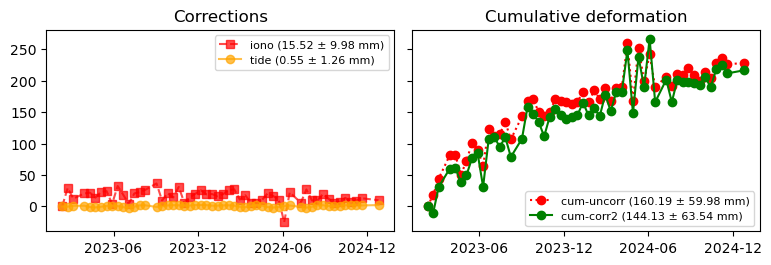

In [36]:

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

cm = 1 / 2.54  # inches per cm

fig, ax = plt.subplots(1, 2, figsize=(20*cm, 7*cm), sharex=True, sharey=True)

if not sbovl:
    mean_trop = np.nanmean(sltd_ts)
    std_trop = np.nanstd(sltd_ts)
    cum_cor_ts2 = cum_uncor_ts - sltd_ts - tide_ts - iono_ts
else:
    cum_cor_ts2 = cum_uncor_ts - tide_ts - iono_ts
#mean
mean_iono = np.nanmean(iono_ts)
mean_tide = np.nanmean(tide_ts)
mean_uncor_cum = np.nanmean(cum_uncor_ts)
mean_cum2 = np.nanmean(cum_cor_ts2)
#std
std_iono = np.nanstd(iono_ts)
std_tide = np.nanstd(tide_ts)
std_uncor_cum = np.nanstd(cum_uncor_ts)
std_cum2 = np.nanstd(cum_cor_ts2)

# ---- Left panel: corrections ----
plt.rcParams["legend.fontsize"] = 8
if sbovl==False:
    ax[0].plot(time, sltd_ts, color="blue", marker="^", linestyle=":", alpha=0.7, label=f"trop ({mean_trop:.2f} ± {std_trop:.2f} mm)")
ax[0].plot(time, iono_ts, color="red", marker="s", linestyle="--", alpha=0.7, label=f"iono ({mean_iono:.2f} ± {std_iono:.2f} mm)")
ax[0].plot(time, tide_ts, color="orange", marker="o", linestyle="-", alpha=0.7, label=f"tide ({mean_tide:.2f} ± {std_tide:.2f} mm)")

# ax[0].set_ylabel("Displacement (mm)")
ax[0].set_title("Corrections")
ax[0].legend()

# ---- Right panel: cumulative deformation ----
ax[1].plot(time, cum_uncor_ts, color="red", marker="o", linestyle=":", label=f"cum-uncorr ({mean_uncor_cum:.2f} ± {std_uncor_cum:.2f} mm)")
# ax[1].plot(time, cum_cor_ts, color="black", marker="o", linestyle="-", label=f"cum-corr ({mean_cum:.2f} ± {std_cum:.2f} mm)")
ax[1].plot(time, cum_cor_ts2, color="green", marker="o", linestyle="-", label=f"cum-corr2 ({mean_cum2:.2f} ± {std_cum2:.2f} mm)")

ax[1].set_title("Cumulative deformation")
ax[1].legend()

# hide y tick labels on second plot
ax[1].tick_params(labelleft=False)

# ----- Sparse x-axis ticks -----
locator = mdates.MonthLocator(interval=6)   # every 3 months
formatter = mdates.DateFormatter('%Y-%m')

for a in ax:
    a.xaxis.set_major_locator(locator)
    a.xaxis.set_major_formatter(formatter)

# # shared x label
# fig.supxlabel("Time")

plt.tight_layout()
# reduce space between panels
fig.subplots_adjust(wspace=0.05)
# if sbovl==False:
#     # plt.savefig("Figure3_cumulative_corrections_range_raw_time_series.png", dpi=300)
# else:
    # plt.savefig("Figure3_cumulative_corrections_sboi_raw_time_series.png", dpi=300)
plt.show()

(a) Uncorrected: average velocity = 121.96 mm/yr, std = 59.98 mm
(b) Uncorrected - iono: average velocity = 127.18 mm/yr, std = 57.65 mm
(c) Uncorrected - iono - tide: average velocity = 126.11 mm/yr, std = 57.37 mm
(d) Uncorrected - iono - tide - interseismic: average velocity = 122.46 mm/yr, std = 55.66 mm
(e) Uncorrected - iono - tide - interseismic - plate: average velocity = 122.34 mm/yr, std = 55.61 mm


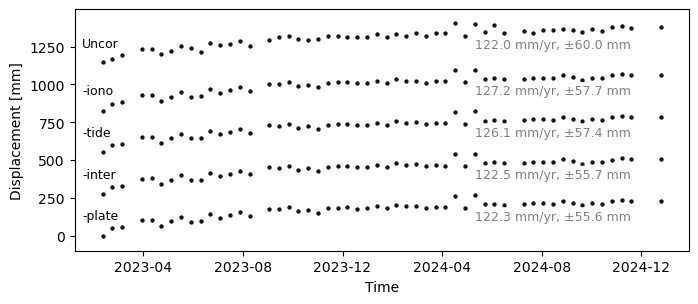

In [42]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import MultipleLocator


cm = 1 / 2.54

# total time span in years from first to last epoch
years = (time.values[-1] - time.values[0]) / np.timedelta64(1, "D") / 365.25

# progressive corrections
cum_uncor_only = cum_uncor_ts
cum_minus_iono= cum_uncor_ts + iono_ts
cum_minus_iono_tide = cum_uncor_ts + iono_ts - tide_ts
cum_minus_iono_tide_inter = cum_uncor_ts + iono_ts - tide_ts - interseismic_ts
cum_minus_all = cum_uncor_ts + iono_ts - tide_ts - interseismic_ts - plate_motion_ts

series = [
    ("(a) Uncorrected", cum_uncor_only),
    ("(b) Uncorrected - iono", cum_minus_iono),
    ("(c) Uncorrected - iono - tide", cum_minus_iono_tide),
    ("(d) Uncorrected - iono - tide - interseismic", cum_minus_iono_tide_inter),
    ("(e) Uncorrected - iono - tide - interseismic - plate", cum_minus_all),
]

short_labels = [
    "Uncor",
    "-iono",
    "-tide",
    "-inter",
    "-plate"
]

# vertical offsets only for display
offset_step = 275  # mm
offsets = np.arange(len(series))[::-1] * offset_step

fig, ax = plt.subplots(figsize=(18 * cm, 8 * cm))

for i, ((label, y), off) in enumerate(zip(series, offsets)):
    y = np.asarray(y, dtype=float)

    net_disp = y[-1] - y[0]              # first-to-last cumulative displacement
    vel_mmyr = net_disp / years          # average velocity in mm/yr
    std = np.nanstd(y)                   # standard deviation

    print(
        f"{label}: "
        # f"net cumulative displacement = {net_disp:.2f} mm, "
        f"average velocity = {vel_mmyr:.2f} mm/yr, "
        f"std = {std:.2f} mm"
    )

    if i == 0:
        off = 1150

    ax.plot(
        time,
        y + off,
        linestyle="None",
        marker="o",
        markersize=2.2,
        color="black",
        alpha=0.85
    )

    ax.text(
        time[int(len(time) * 0.68)],
        off + np.nanmedian(y)-100,
        f"{vel_mmyr:.1f} mm/yr, ±{std:.1f} mm",
        fontsize=9,
        color="gray",
        ha="left",
        va="bottom",
        bbox=dict(
            facecolor="white",
            edgecolor="none",   # or "black" if you want border
            alpha=0.8,
            boxstyle="round,pad=0.2"
        )
    )
    
    ax.text(
        time[0] - pd.Timedelta(days=25),
        off + 0.7*np.nanmedian(y),
        short_labels[i],
        fontsize=9,
        ha="left",
        va="center",
        color="black",
        bbox=dict(
            facecolor="white",
            edgecolor="none",
            alpha=0.8,
            boxstyle="round,pad=0.2"
        )
    )
    

ax.set_ylabel("Displacement [mm]")
ax.set_xlabel("Time")

locator = mdates.MonthLocator(interval=4)
# locator = mdates.MonthLocator(bymonth=[2, 4, 6, 8, 10, 12])
formatter = mdates.DateFormatter("%Y-%m")
formatter = mdates.DateFormatter("%Y-%m")
ax.xaxis.set_major_locator(locator)
ax.xaxis.set_major_formatter(formatter)
ax.yaxis.set_major_locator(MultipleLocator(250))
ax.set_ylim(bottom=-100, top=1499)
ax.tick_params(axis="x", rotation=0)
ax.grid(False)

plt.tight_layout()
plt.savefig("Figure3_cumulative_corrections_sboi_raw_time_series.png")
plt.show()

In [43]:
corrected_cum = (
    cum_uncor.cum.isel(time=-1)
    - plate_motion_cumulative_ref.isel(time=-1)
    - interseismic_velo_cumulative_ref.isel(time=-1)
    - cum_uncor.iono.isel(time=-1)
    - cum_uncor.tide.isel(time=-1)
)

DEM already exists!


getfattr: Removing leading '/' from absolute path names
getfattr: Removing leading '/' from absolute path names
getfattr: Removing leading '/' from absolute path names
getfattr: Removing leading '/' from absolute path names
getfattr: Removing leading '/' from absolute path names
getfattr: Removing leading '/' from absolute path names
getfattr: Removing leading '/' from absolute path names
getfattr: Removing leading '/' from absolute path names
getfattr: Removing leading '/' from absolute path names
getfattr: Removing leading '/' from absolute path names
getfattr: Removing leading '/' from absolute path names
getfattr: Removing leading '/' from absolute path names


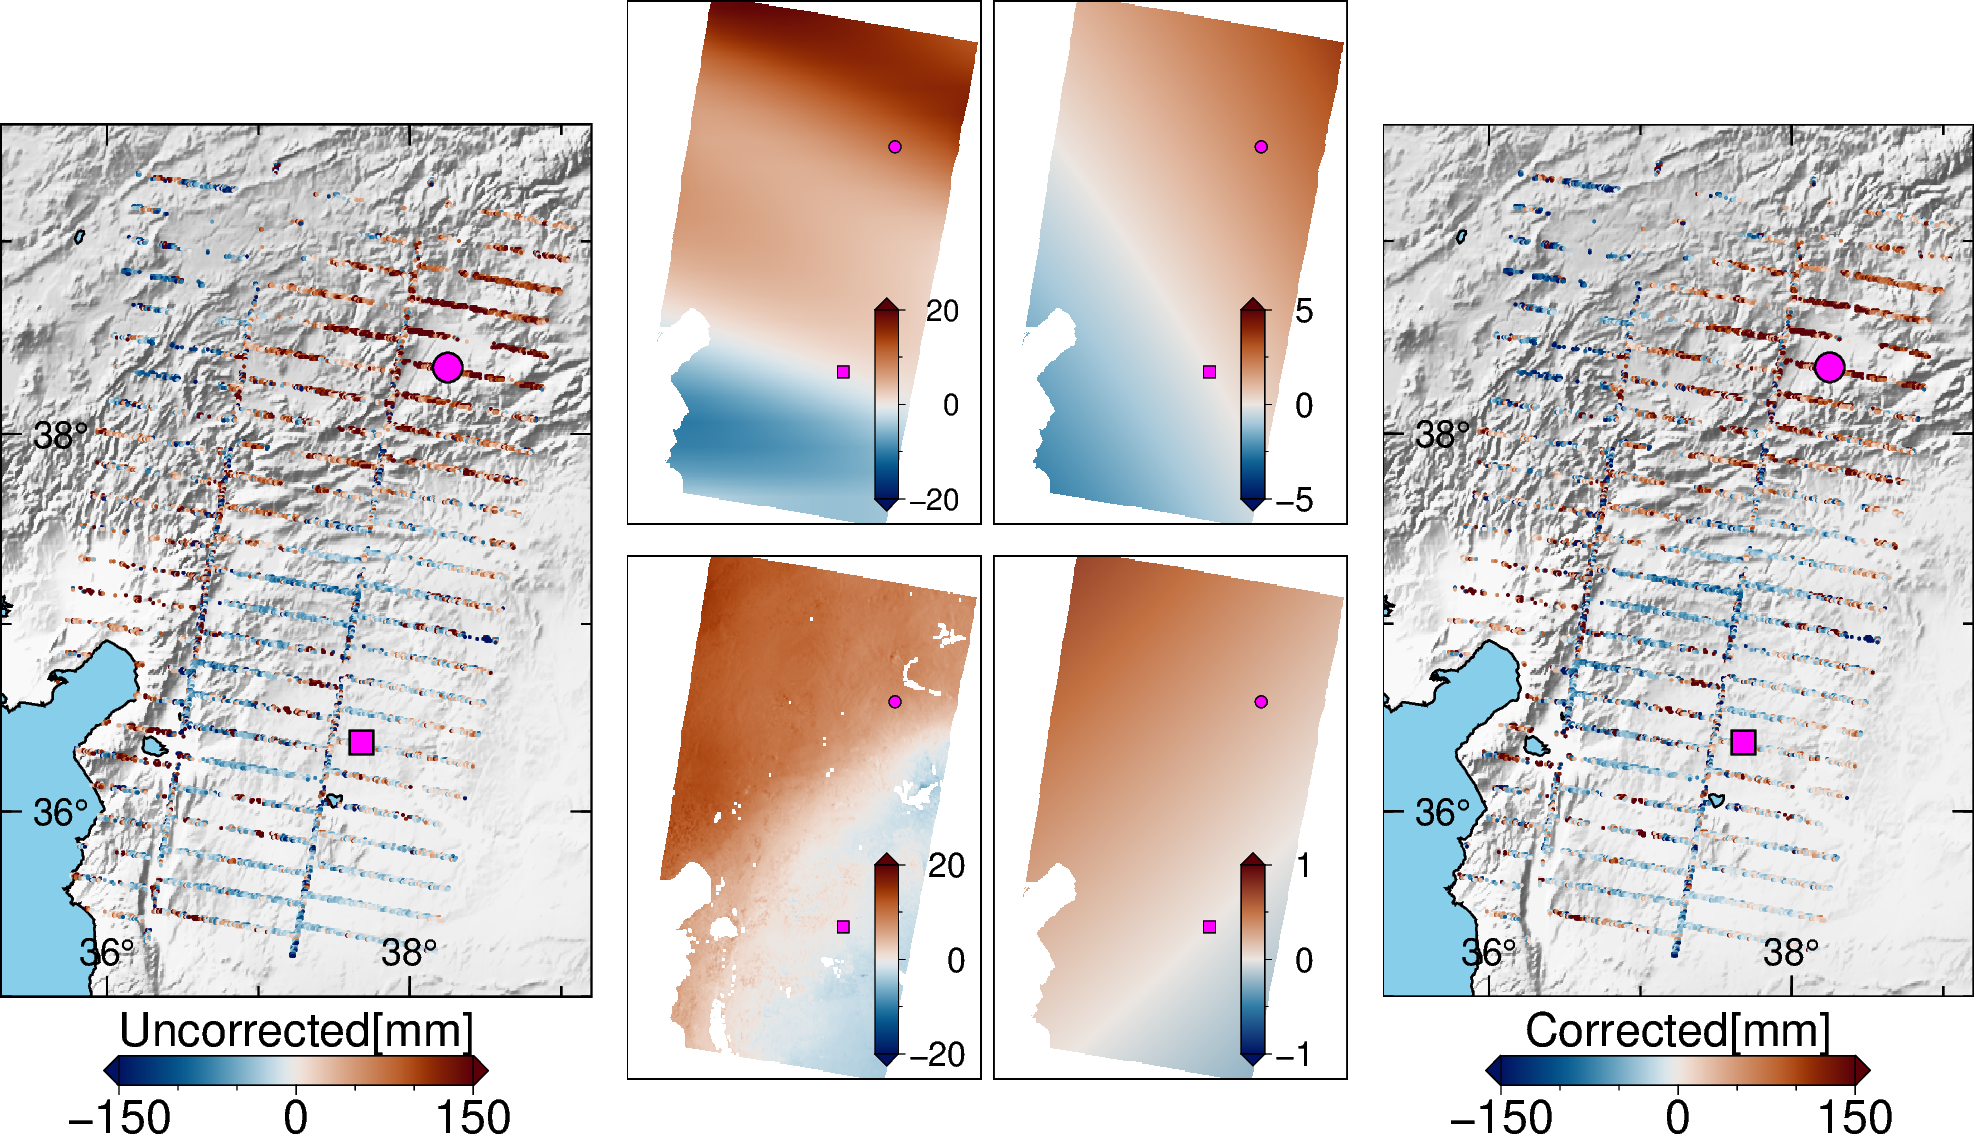

In [47]:
import pygmt
##DEM file
dem_file='earth_relief_fullAHB_30s.nc'
batchdir = os.environ.get("BATCH_CACHE_DIR")
dem = os.path.join(batchdir, dem_file)
#####
# DEM downloading
if not os.path.exists(dem):
    print('DEM is downloading please wait! After downloading, the process will be faster!')
    try:
        lonmin_lamb = 1  # degrees East
        lonmax_lamb = 80
        latmin_lamb = 25
        latmax_lamb = 60
        RR_used = [lonmin_lamb, lonmax_lamb, latmin_lamb, latmax_lamb]
        dem_resolution='30s'
        # Download the earth relief data and save it to a file
        grid = pygmt.datasets.load_earth_relief(resolution=dem_resolution, region=RR_used)
        # Saving the grid to a NetCDF file
        grid.to_netcdf(dem)
        print(f"Data successfully downloaded and saved to {dem}")
    except Exception as e:
        print(f"An error occurred: {e}")
else:
    print(f'DEM already exists!')

##fault file
# GEMS_dir='/scratch/eemne/GEMS'
# fault_file=f'{GEMS_dir}/actives/TR_active_faults.shp'

#plot region
plot_region = [35.3, 39.2, 35, 39.6]
#####
fig = pygmt.Figure()
pygmt.config(
    MAP_FRAME_TYPE="plain",
    FONT_ANNOT_PRIMARY="20p,Helvetica,black",   # longitude ticks
    FONT_LABEL="20p,Helvetica,black",       # axis labels
    FORMAT_GEO_MAP='D',
    MAP_FRAME_PEN="0.5p,black",  # 2-point thick black frame line
    MAP_DEFAULT_PEN="0.5p,black",
    # MAP_TICK_PEN_PRIMARY="1p",
    # MAP_TICK_LENGTH_PRIMARY="5p",
    MAP_TICK_LENGTH="5p"
)
## Figure a --plotting Uncorrected deformation
#Plot background DEM
fig.basemap(projection="M5c", region=plot_region, frame=['WSne'])
pygmt.makecpt(cmap="gray", series=[-200, 10000, 3000], continuous=True, reverse=True)
fig.grdimage(grid=dem,cmap=True,region=plot_region,shading=True,frame=False)
fig.coast(shorelines="black", water="skyblue")
#plotting uncorrected deformation
cmap = pygmt.makecpt(cmap="vik", series=[-150, 150, 1], continuous=True)
# fig.grdimage(grid=cum_uncor.cum[-1], cmap=cmap, region=plot_region, nan_transparent=True)
Vn_xyz='temp_Vn.xyz'
da_to_xyz(cum_uncor.cum[-1], Vn_xyz,varname="Vn")
fig.plot(data=Vn_xyz, style="c0.03c", fill="+z", cmap=True)
os.remove(Vn_xyz)

###colorbar
pygmt.config(MAP_FRAME_TYPE="plain", FONT_ANNOT_PRIMARY="25p,Helvetica,black", FONT_LABEL="25p,Helvetica, black")
fig.colorbar(
    frame='a150f50+lUncorrected[mm]',  # Label for the color bar
    cmap=True,
    position="JBC+o0c/0.5c+w3c/0.25c+ml+h+e"
    # truncate=[vmin, vmax],  # Color bar starts at 0 (excluding ocean DEM values)
    # box="+gwhite@50"
)

# plotting reference points
# circle for point1
fig.plot(
    x=point1[0],
    y=point1[1],
    style="c0.25c",      # circle, diameter 0.25 cm
    fill="magenta1",
    pen="0.5p,black"
)

# rectangle for reference point
fig.plot(
    x=reference[0],
    y=reference[1],
    style="r0.20c/0.20c",  # rectangle width/height
    fill="magenta1",
    pen="0.5p,black"
)

#last basemap
pygmt.config(MAP_FRAME_TYPE="inside", FONT_ANNOT="9p,Helvetica,black")
fig.basemap(projection="M5c", region=plot_region, frame=["x2f1","y2f1",'WSne'])

#Figure b --plotting iono
fig.shift_origin(xshift='5.3c', yshift='4c')
#Plot background DEM
fig.basemap(projection="M3c", region=plot_region, frame=['wsne'])
#plotting uncorrected deformation
cmap = pygmt.makecpt(cmap="vik", series=[-20, 20, 1], continuous=True)
fig.grdimage(grid=cum_uncor_ref.iono[-1], cmap=cmap, region=plot_region, nan_transparent=True)

###colorbar
pygmt.config(MAP_FRAME_TYPE="plain", FONT_ANNOT_PRIMARY="22p,Helvetica,black", FONT_LABEL="20p,Helvetica, black")
fig.colorbar(
    frame='a20f10',  # Label for the color bar
    cmap=True,
    position="JMR+o-0.9c/-1.2c+w1.6c/0.2c+ml+e"
    # truncate=[vmin, vmax],  # Color bar starts at 0 (excluding ocean DEM values)
    # box="+gwhite@50"
)

# plotting reference points
# circle for point1
fig.plot(
    x=point1[0],
    y=point1[1],
    style="c0.1c",      # circle, diameter 0.25 cm
    fill="magenta1",
    pen="0.2p,black"
)

# rectangle for reference point
fig.plot(
    x=reference[0],
    y=reference[1],
    style="r0.1c/0.1c",  # rectangle width/height
    fill="magenta1",
    pen="0.2p,black"
)

#last basemap
pygmt.config(MAP_FRAME_TYPE="inside", FONT_ANNOT="9p,Helvetica,black")
fig.basemap(projection="M3c", region=plot_region, frame=["x200f100","y200f100",'WSne'])

#Figure c --plotting tide
fig.shift_origin(xshift='3.1c')
#Plot background DEM
fig.basemap(projection="M3c", region=plot_region, frame=['wsne'])
#plotting uncorrected deformation
cmap = pygmt.makecpt(cmap="vik", series=[-5, 5, 1], continuous=True)
fig.grdimage(grid=cum_uncor_ref.tide[-1], cmap=cmap, region=plot_region, nan_transparent=True)

###colorbar
pygmt.config(MAP_FRAME_TYPE="plain", FONT_ANNOT_PRIMARY="25p,Helvetica,black", FONT_LABEL="25p,Helvetica, black")
fig.colorbar(
    frame='a5f2.5',  # Label for the color bar
    cmap=True,
    position="JMR+o-0.9c/-1.2c+w1.6c/0.2c+ml+e"
    # truncate=[vmin, vmax],  # Color bar starts at 0 (excluding ocean DEM values)
    # box="+gwhite@50"
)

# plotting reference points
# circle for point1
fig.plot(
    x=point1[0],
    y=point1[1],
    style="c0.1c",      # circle, diameter 0.25 cm
    fill="magenta1",
    pen="0.2p,black"
)

# rectangle for reference point
fig.plot(
    x=reference[0],
    y=reference[1],
    style="r0.1c/0.1c",  # rectangle width/height
    fill="magenta1",
    pen="0.2p,black"
)

#last basemap
pygmt.config(MAP_FRAME_TYPE="inside", FONT_ANNOT="9p,Helvetica,black")
fig.basemap(projection="M3c", region=plot_region, frame=["x200f100","y200f100",'WSne'])

#Figure d --plotting interseismic
fig.shift_origin(xshift='-3.1c',  yshift='-4.7c')
#Plot background DEM
fig.basemap(projection="M3c", region=plot_region, frame=['wsne'])
#plotting uncorrected deformation
cmap = pygmt.makecpt(cmap="vik", series=[-20, 20, 1], continuous=True)
fig.grdimage(grid=interseismic_velo_cumulative_ref.isel(time=-1), cmap=cmap, region=plot_region, nan_transparent=True)

###colorbar
pygmt.config(MAP_FRAME_TYPE="plain", FONT_ANNOT_PRIMARY="25p,Helvetica,black", FONT_LABEL="25p,Helvetica, black")
fig.colorbar(
    frame='a20f10',  # Label for the color bar
    cmap=True,
    position="JMR+o-0.9c/-1.2c+w1.6c/0.2c+ml+e"
    # truncate=[vmin, vmax],  # Color bar starts at 0 (excluding ocean DEM values)
    # box="+gwhite@50"
)

# plotting reference points
# circle for point1
fig.plot(
    x=point1[0],
    y=point1[1],
    style="c0.1c",      # circle, diameter 0.25 cm
    fill="magenta1",
    pen="0.2p,black"
)

# rectangle for reference point
fig.plot(
    x=reference[0],
    y=reference[1],
    style="r0.1c/0.1c",  # rectangle width/height
    fill="magenta1",
    pen="0.2p,black"
)

#last basemap
pygmt.config(MAP_FRAME_TYPE="inside", FONT_ANNOT="9p,Helvetica,black")
fig.basemap(projection="M3c", region=plot_region, frame=["x200f100","y200f100",'WSne'])

#Figure e --plotting plate motion
fig.shift_origin(xshift='3.1c')
#Plot background DEM
fig.basemap(projection="M3c", region=plot_region, frame=['wsne'])
#plotting uncorrected deformation
cmap = pygmt.makecpt(cmap="vik", series=[-1, 1, 0.5], continuous=True)
fig.grdimage(grid=plate_motion_cumulative_ref.isel(time=-1), cmap=cmap, region=plot_region, nan_transparent=True)

###colorbar
pygmt.config(MAP_FRAME_TYPE="plain", FONT_ANNOT_PRIMARY="25p,Helvetica,black", FONT_LABEL="25p,Helvetica, black")
fig.colorbar(
    frame='a1f0.5',  # Label for the color bar
    cmap=True,
    position="JMR+o-0.9c/-1.2c+w1.6c/0.2c+ml+e"
    # truncate=[vmin, vmax],  # Color bar starts at 0 (excluding ocean DEM values)
    # box="+gwhite@50"
)

# plotting reference points
# circle for point1
fig.plot(
    x=point1[0],
    y=point1[1],
    style="c0.1c",      # circle, diameter 0.25 cm
    fill="magenta1",
    pen="0.2p,black"
)

# rectangle for reference point
fig.plot(
    x=reference[0],
    y=reference[1],
    style="r0.1c/0.1c",  # rectangle width/height
    fill="magenta1",
    pen="0.2p,black"
)

#last basemap
pygmt.config(MAP_FRAME_TYPE="inside", FONT_ANNOT="9p,Helvetica,black")
fig.basemap(projection="M3c", region=plot_region, frame=["x200f100","y200f100",'WSne'])


#Figure f --plotting corrections
fig.shift_origin(xshift='3.3c',  yshift='0.7c')
#Plot background DEM
fig.basemap(projection="M5c", region=plot_region, frame=['WSne'])
pygmt.makecpt(cmap="gray", series=[-200, 10000, 3000], continuous=True, reverse=True)
fig.grdimage(grid=dem,cmap=True,region=plot_region,shading=True,frame=False)
fig.coast(shorelines="black", water="skyblue")
#plotting uncorrected deformation
cmap = pygmt.makecpt(cmap="vik", series=[-20, 20, 1], continuous=True)
# fig.grdimage(grid=interseismic_velo_cumulative_ref.isel(time=-1) , cmap=cmap, region=plot_region, nan_transparent=True)
cmap = pygmt.makecpt(cmap="vik", series=[-150, 150, 1], continuous=True)
Vn_xyz='temp_Vn.xyz'
da_to_xyz(corrected_cum, Vn_xyz,varname="Vn")
fig.plot(data=Vn_xyz, style="c0.03c", fill="+z", cmap=True)
os.remove(Vn_xyz)

###colorbar
pygmt.config(MAP_FRAME_TYPE="plain", FONT_ANNOT_PRIMARY="25p,Helvetica,black", FONT_LABEL="25p,Helvetica, black")
fig.colorbar(
    frame='a150f50+lCorrected[mm]',  # Label for the color bar
    cmap=True,
    position="JBC+o0c/0.5c+w3c/0.25c+ml+h+e"
    # truncate=[vmin, vmax],  # Color bar starts at 0 (excluding ocean DEM values)
    # box="+gwhite@50"
)


# plotting reference points
# circle for point1
fig.plot(
    x=point1[0],
    y=point1[1],
    style="c0.25c",      # circle, diameter 0.25 cm
    fill="magenta1",
    pen="0.5p,black"
)

# rectangle for reference point
fig.plot(
    x=reference[0],
    y=reference[1],
    style="r0.20c/0.20c",  # rectangle width/height
    fill="magenta1",
    pen="0.5p,black"
)


#last basemap
pygmt.config(MAP_FRAME_TYPE="inside", FONT_ANNOT="9p,Helvetica,black")
fig.basemap(projection="M5c", region=plot_region, frame=["x2f1","y2f1",'WSne'])


fig.savefig("Figure3_cumulative_corrections_sboi_raw.png")
fig.show()
